## Import Libraries and data

In [1]:
# base modules
from pathlib import Path
import logging
from collections import OrderedDict

# for manipulating data
import numpy as np
import pandas as pd
import math
from typing import Callable
import copy
import re
from pandas.api.types import is_string_dtype, is_numeric_dtype

# for Machine Learning
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV

# for visualization
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# for package auto reload
%load_ext autoreload
%autoreload 2

# for better rendering of plots in jupyter notebook
%matplotlib inline

In [3]:
def fix_missing(df, col, name, na_dict):
    """
    Fill missing data in a column of df with the median, and add a {name}_na column
    which specifies if the data was missing.
    """
    if is_numeric_dtype(col):
        if pd.isnull(col).sum() or (name in na_dict):
            df[name + '_na'] = pd.isnull(col)
            filler = na_dict[name] if name in na_dict else col.median()
            df[name] = col.fillna(filler)
            na_dict[name] = filler
    return na_dict

    
def numericalize(df: pd.DataFrame, col: str, name: str, max_n_cat: int | None) -> pd.DataFrame:
    """
    Changes the column col from a categorical type to it's integer codes.
    """
    df = copy.deepcopy(df)
    if (not is_numeric_dtype(col) 
        and (max_n_cat is None or len(col.cat.categories) > max_n_cat)):
        df[name] = pd.Categorical(col).codes + 1
    return df

In [4]:
def process_df(
    df: pd.DataFrame, 
    y_field: str | None = None, 
    skip_flds: list = [],
    ignore_flds: list = [], 
    na_dict: dict = {},
    preproc_fn: Callable = None, 
    max_n_cat = None, 
    ):
    """
    Take a dataframe df and splits off the response variable, and
    changes the df into an entirely numeric dataframe. For each column of df 
    which is not in skip_flds nor in ignore_flds, na values are replaced by the
    median value of the column.
    """
    df = copy.deepcopy(df)
    
    df_ignored = df.loc[:, ignore_flds]
    df = df.drop(columns = ignore_flds)
    
    if preproc_fn: 
        preproc_fn(df)
        
    if y_field is None: 
        y = None
    else:
        if not is_numeric_dtype(df[y_field]): 
            df[y_field] = pd.Categorical(df[y_field]).codes
        y = df[y_field].values
        skip_flds += [y_field]
    
    df = df.drop(columns = skip_flds)

    na_dict_initial = na_dict.copy()
    for n, c in df.items(): 
        na_dict = fix_missing(df, c, n, na_dict)
    
    if len(na_dict_initial) > 0:
        df = df.drop(
            [a + '_na' for a in list(set(na_dict.keys()) - set(na_dict_initial.keys()))], 
            axis = 1,
        )
    for n,c in df.items(): 
        df = numericalize(df, c, n, max_n_cat)
        
    df = pd.get_dummies(df, dummy_na = True)
    df = pd.concat([df_ignored, df], axis = 1)
    return (df, y, na_dict)


In [5]:
def reduce_mem_usage(df):

    start_mem = df.memory_usage().sum() 
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() 
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    return df

In [6]:
sample_feature = reduce_mem_usage(pd.read_csv('data_for_tree.csv')) #data for tree.csv comes from Step_2_Feature_Engineering.ipynb

Memory usage of dataframe is 63691972.00 MB
Memory usage after optimization is: 17117446.00 MB
Decreased by 73.1%


In [7]:
continuous_feature_names = [x for x in sample_feature.columns if x not in ['price','brand','model','brand']]

In [8]:
df, y, nas = process_df(sample_feature, 'price')

In [9]:
print(df.shape)
df.head()

(199037, 48)


,SaleID,name,model,brand,bodyType,fuelType,gearbox,power,kilometer,notRepairedDamage,...,power_bin,model_na,bodyType_na,fuelType_na,gearbox_na,train_na,test_na,used_time_na,city_na,power_bin_na
0,0,736,30.0,6,1.0,0.0,0.0,60,12.5,2,...,5.0,False,False,False,False,False,True,False,False,False
1,1,2262,40.0,1,2.0,0.0,0.0,0,15.0,1,...,11.0,False,False,False,False,False,True,False,False,True
2,2,14874,115.0,15,1.0,0.0,0.0,163,12.5,2,...,16.0,False,False,False,False,False,True,False,False,False
3,3,71865,109.0,10,0.0,0.0,1.0,193,15.0,2,...,19.0,False,False,False,False,False,True,False,True,False
4,4,111080,110.0,5,1.0,0.0,0.0,68,5.0,2,...,6.0,False,False,False,False,False,True,False,False,False


In [10]:
len(y)
y

array([1850., 3600., 6222., ...,   nan,   nan,   nan],
      shape=(199037,), dtype=float32)

---
## Basic

Now I want to make sure that if y is non numeric, change it to NaN, then get a mask

Function: Give y a Series and then make it to numeric, reproduce again mask -> use new mask to filter again X and y, if X still have Nan, fill again with median

This section overlaps somewhat with the previous one, but it improves robustness. We must make sure that there is no Nan in X and y, and their numbers of rows must be the same, otherwise we can not train the model.

In [11]:
y_series = pd.to_numeric(pd.Series(y), errors='coerce')# make sure y is pandas.series/to numeric, change non numeric to NaN
mask = y_series.notna()# get the mask again
#use the same mask to filter X and y
X = df.loc[mask].copy()

y = y_series.loc[mask].astype(float).to_numpy().ravel()

# if X still has NaN，fill again
if X.isna().any().any():
    X = X.fillna(X.median(numeric_only=True))

#self-check before training: check the rows of X and y
print("X rows:", X.shape[0], "y rows:", y.shape[0], "X cols:", X.shape[1])
assert X.shape[0] == y.shape[0]

#train the model(use X, not original df): use RandomForestRegressor with n_estimators=200(how many trees), n_jobs=-1(all cpu multi-processing), random_state=42(reproducibility)
model = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
model.fit(X, y)

X rows: 149037 y rows: 149037 X cols: 48


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Take the sample in row 0 and calculate its "true price" exponential back-transform, presumably because you previously performed a log transformation on y.

In [12]:
x = df.iloc[0] # get the first row of df as a sample input, note that we use df-original, not X
y_true = np.exp(y[0]) # exp(log(price))=price
x, y_true

(SaleID                          0
 name                          736
 model                        30.0
 brand                           6
 bodyType                      1.0
 fuelType                      0.0
 gearbox                       0.0
 power                          60
 kilometer                    12.5
 notRepairedDamage               2
 seller                          0
 offerType                       0
 v_0                      43.34375
 v_1                      3.966797
 v_2                      0.050262
 v_3                      2.160156
 v_4                      1.143555
 v_5                      0.235718
 v_6                       0.10199
 v_7                      0.129517
 v_8                      0.022812
 v_9                      0.097473
 v_10                    -2.880859
 v_11                     2.804688
 v_12                    -2.419922
 v_13                      0.79541
 v_14                     0.914551
 train                         1.0
 test               

In [13]:
x = [x]                   # wrap the data point into a list -（1，n_features）
y_pred = model.predict(x) # prediction, as list
y_pred = y_pred[0]        # take first element of predicted list
y_pred = np.exp(y_pred)   # exponentialize
y_pred

np.float64(inf)

In [14]:
model.score(X, y) #give the R^2 of the model on the training data

0.9950527226149228

---

### Seperate the data to trainning set, validation set and small test dataset

In [15]:
n_total   = len(df)          
n_test= n_total - len(y)  
X_labeled = df.iloc[: n_total - n_test].copy() 
n_small = 20000


# do simple split
n_valid = 50000     
n_train = len(X_labeled) - n_valid

def split_vals(a, n):
    return a[:n].copy(), a[n:].copy()

# main splits
X_train, X_valid = split_vals(X_labeled, n_train)
y_train, y_valid = split_vals(y, n_train)

# small subset for fast experiments
X_small, _ = split_vals(X_train, n_small)
y_small, _ = split_vals(y_train, n_small)

# check sizes
print(f'Number of small training data points: X = {X_small.shape}, y = {y_small.shape}')
print(f'Number of full training data points: X = {X_train.shape}, y = {y_train.shape}')
print(f'Number of validation data points: X = {X_valid.shape}, y = {y_valid.shape}')

Number of small training data points: X = (20000, 48), y = (20000,)
Number of full training data points: X = (99037, 48), y = (99037,)
Number of validation data points: X = (50000, 48), y = (50000,)


- define root mean squared error

In [16]:
def rmse(y_gold, y_pred): 
    return math.sqrt(((y_gold - y_pred)**2).mean())

- define print score(train/valid+oob)

In [17]:
def print_score(m, X_train, y_train, X_valid, y_valid):
    print('RMSE on train set: {:.4f}'.format(rmse(m.predict(X_train), y_train)))
    print('RMSE on valid set: {:.4f}'.format(rmse(m.predict(X_valid), y_valid)))
    print('R^2 on train set: {:.4f}'.format(m.score(X_train, y_train)))
    print('R^2 on valid set: {:.4f}'.format(m.score(X_valid, y_valid)))
    if hasattr(m, 'oob_score_'): print('R^2 on oob set: {:.4f}'.format(m.oob_score_))
    return

### Train a baseline model

Here we only have 10 trees

First small-scale experiment

In [18]:
base_model = RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=42)
base_model.fit(X_small, y_small)
print_score(base_model, X_small, y_small, X_valid, y_valid)

RMSE on train set: 739.7063
RMSE on valid set: 1772.9779
R^2 on train set: 0.9889
R^2 on valid set: 0.9359


We can see that both train and valid set have a high r_2, which means that the model had already gotten some positive learning signal.

However, the RMSE(VALID) is way higher than RMSE(TRAIN), means that there is some overfitting, because we only had 10 trees.

Then we use X_train and y_train to do a full-scale experiment

In [19]:
base_model = RandomForestRegressor(n_estimators = 10, n_jobs = -1, random_state = 42)

%time base_model.fit(X_train, y_train)
print_score(base_model, X_train, y_train, X_valid, y_valid)

CPU times: total: 29.8 s
Wall time: 3.45 s
RMSE on train set: 621.6054
RMSE on valid set: 1471.8495
R^2 on train set: 0.9921
R^2 on valid set: 0.9559


Compare to the small-scale test, r_2 increased and rmse decreased, means that more data can help the model more stable.
But rmse(train) still smaller than rmse(valid), means that overfitting still exist.

### One decision tree

Training objective: To provide a control over a small sample set X_small using a single tree (high interpretability).

First test:

**max_depth=3**: Limits the tree to a very shallow depth, resulting in high bias and preventing overfitting but also underfitting.

Other parameters are default values.

In [20]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42, 
)

In [21]:
%time model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

CPU times: total: 109 ms
Wall time: 106 ms
RMSE on train set: 2895.2475
RMSE on valid set: 3110.2513
R^2 on train set: 0.8306
R^2 on valid set: 0.8029


R_2 means underfitting, because the depth is too shallow, and only 20,000 samples are used;

Single trees have high variance, poor stability, and weak generalization ability.

→ This explains why ensemble learning is necessary: ​​Random forests vote/average many weak learners, thereby reducing variance and making the overall results more accurate and stable.

Second test:

Now **max_depth=15**

In [22]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42,
)

In [23]:
%time model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

CPU times: total: 484 ms
Wall time: 473 ms
RMSE on train set: 430.7132
RMSE on valid set: 2298.3079
R^2 on train set: 0.9963
R^2 on valid set: 0.8924


Depth 15 -> Each tree can almost perfectly segment the training samples with extremely low error.

Train set performance is extremely high (R²≈1), but validation set performance declines significantly.

This indicates that the trees have learned the noise in the training samples, resulting in poorer generalization ability. This is a typical overfitting

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree as _plot_tree

def draw_tree(model_dt, feature_names=None, precision=3,
              max_depth=3,  
              filename=None, dpi=200, figsize=(22, 10)):

    fig = plt.figure(figsize=figsize)
    ax = plt.gca()
    _plot_tree(
        model_dt,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        precision=precision,
        max_depth=max_depth,
        ax=ax
    )
    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight")
    return fig 



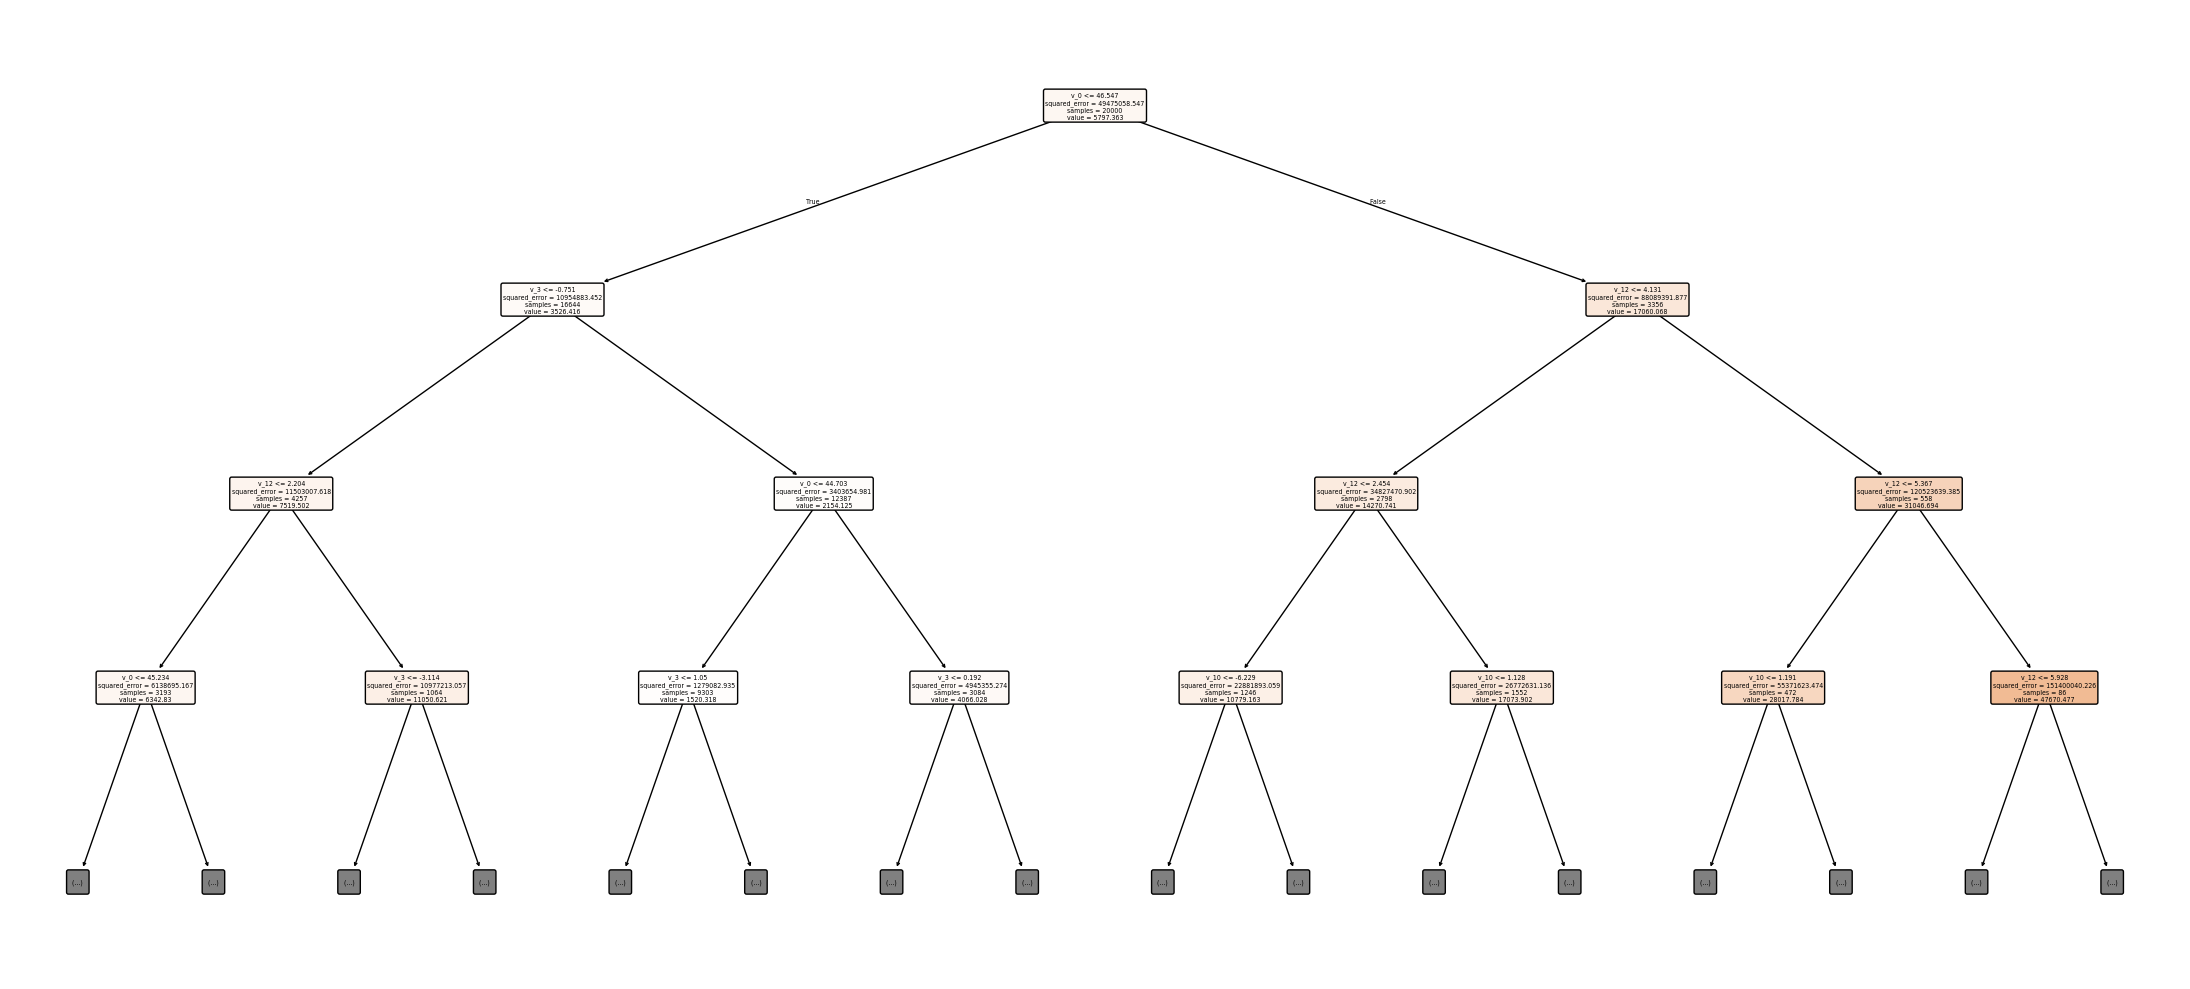

In [25]:
draw_tree(model_dt, feature_names = X_small.columns.tolist(), precision = 3)

A single tree model and no bootstrap = Decision tree regressor, max depth=3

`n_estimators=1 + bootstrap=False` means "a decision tree trained with these hyperparameters", without the "ensemble effect of random forest" (no multiple trees, no voting/averaging).

In [26]:
model_rf = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 1, # = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = False, # default = True 
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

In [27]:
%time model_rf.fit(X_small, y_small)
print_score(model_rf, X_small, y_small, X_valid, y_valid)

CPU times: total: 125 ms
Wall time: 119 ms
RMSE on train set: 2895.2475
RMSE on valid set: 3110.2513
R^2 on train set: 0.8306
R^2 on valid set: 0.8029


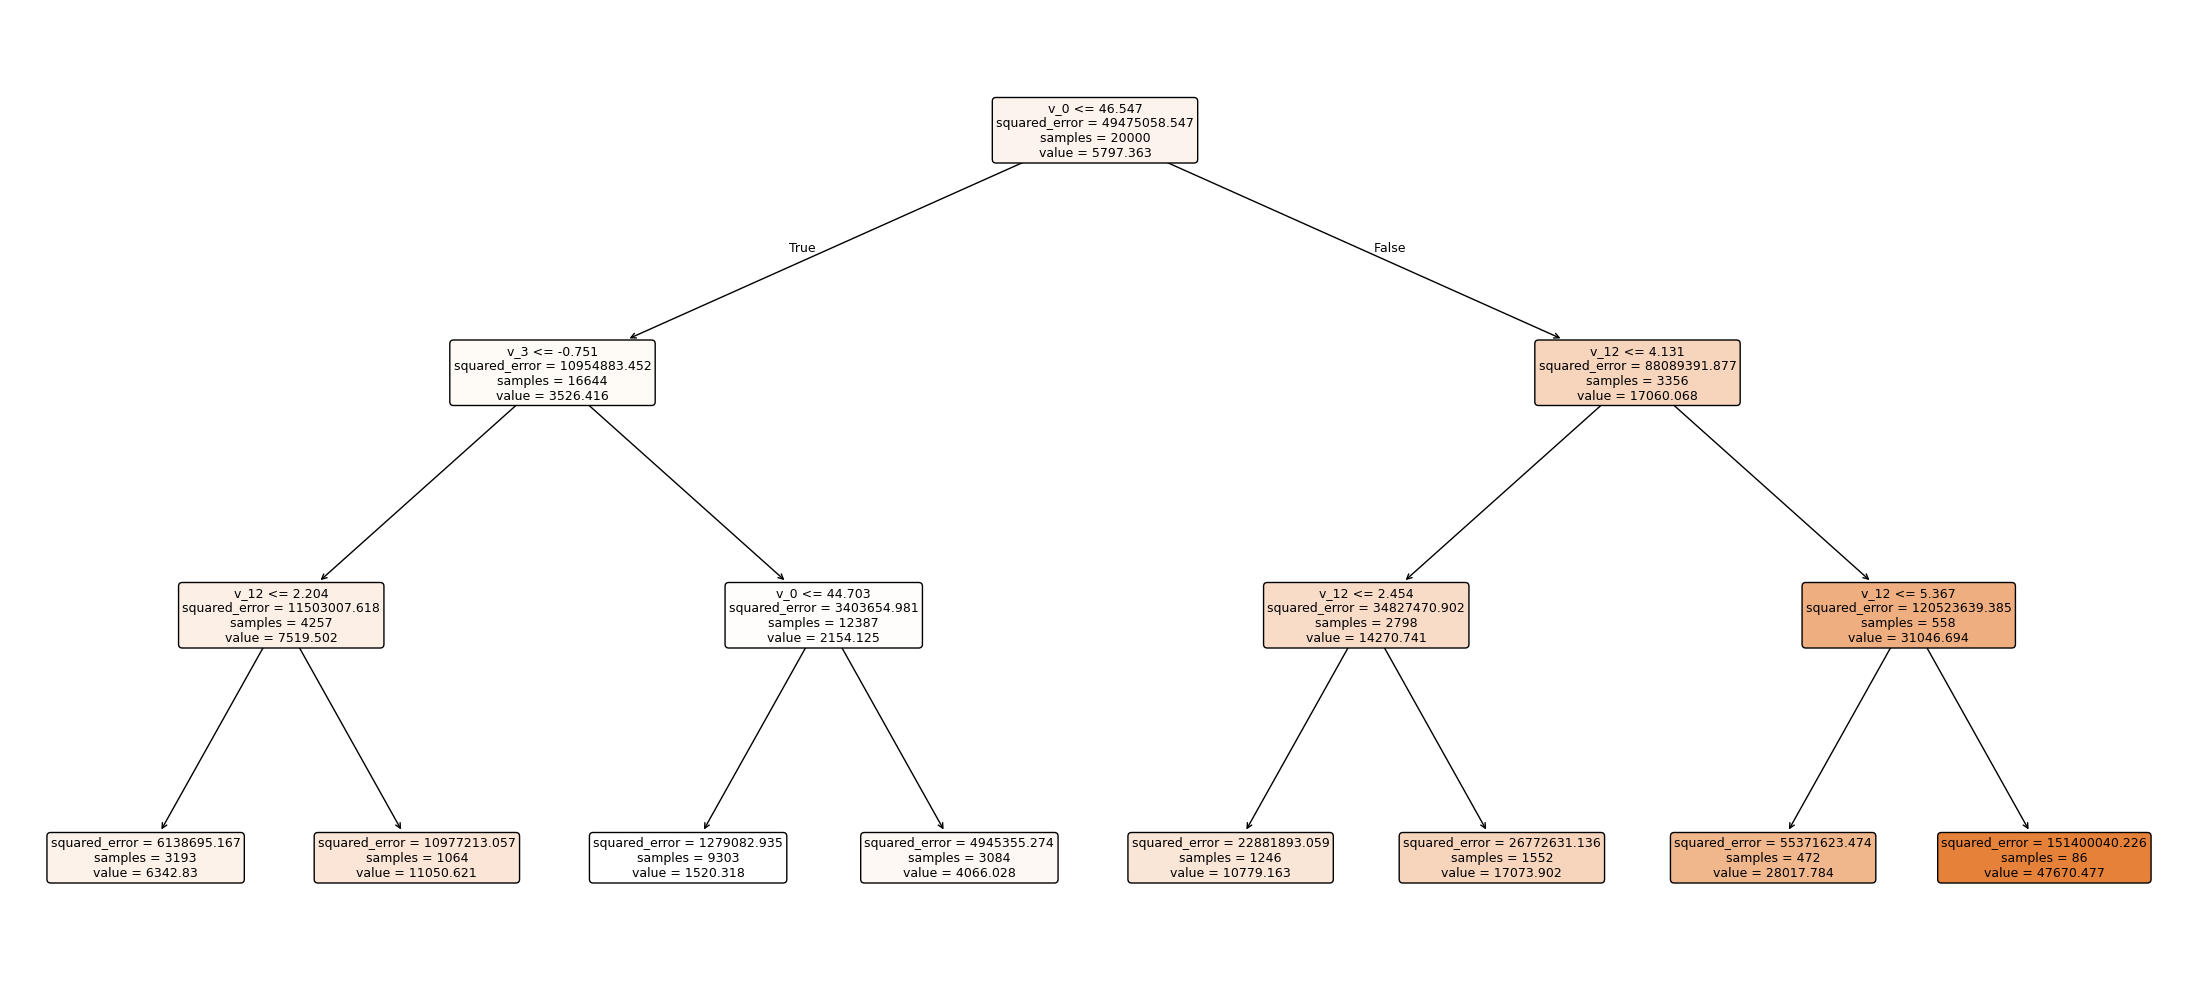

In [28]:
draw_tree(model_rf.estimators_[0], X_small.columns.tolist(), precision = 3)

Now 2 trees

| **Parameters** | **Previous** | **Current** | **Effect** |
|----------------|---------------|--------------|-------------|
| **n_estimators** | 1 | 2 | From a single tree → two trees (start ensemble) |
| **bootstrap** | False | True | Enable random sampling of samples, increasing inter-tree differences |
| **max_samples** | None | 0.5 | Each tree only sees half the data (bagging effect is more obvious) |
| **max_features** | None | 0.5 | Each tree only sees half of the features (decorrelation) |
| **max_depth** | 3 | 3 | Still limits depth, maintaining the tendency of single trees to underfit (improvement can be seen on the validation set) |


In [29]:
model_rf = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 2, # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 3,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = 0.5, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True, # default = True 
    oob_score = False, # not enough trees for oob
    max_samples = 0.5, # use 50% of data for each tree

    # extra parameters
    warm_start = False, #not reusing previous trees
    n_jobs = -1,
    verbose = 0, 
)

In [30]:
%time model_rf.fit(X_small, y_small)
print_score(model_rf, X_small, y_small, X_valid, y_valid)

CPU times: total: 46.9 ms
Wall time: 43.8 ms
RMSE on train set: 2921.9766
RMSE on valid set: 3106.3203
R^2 on train set: 0.8274
R^2 on valid set: 0.8034


Compare to the previous, The performance of the validation set(r_2(valid)) has been slightly improved.

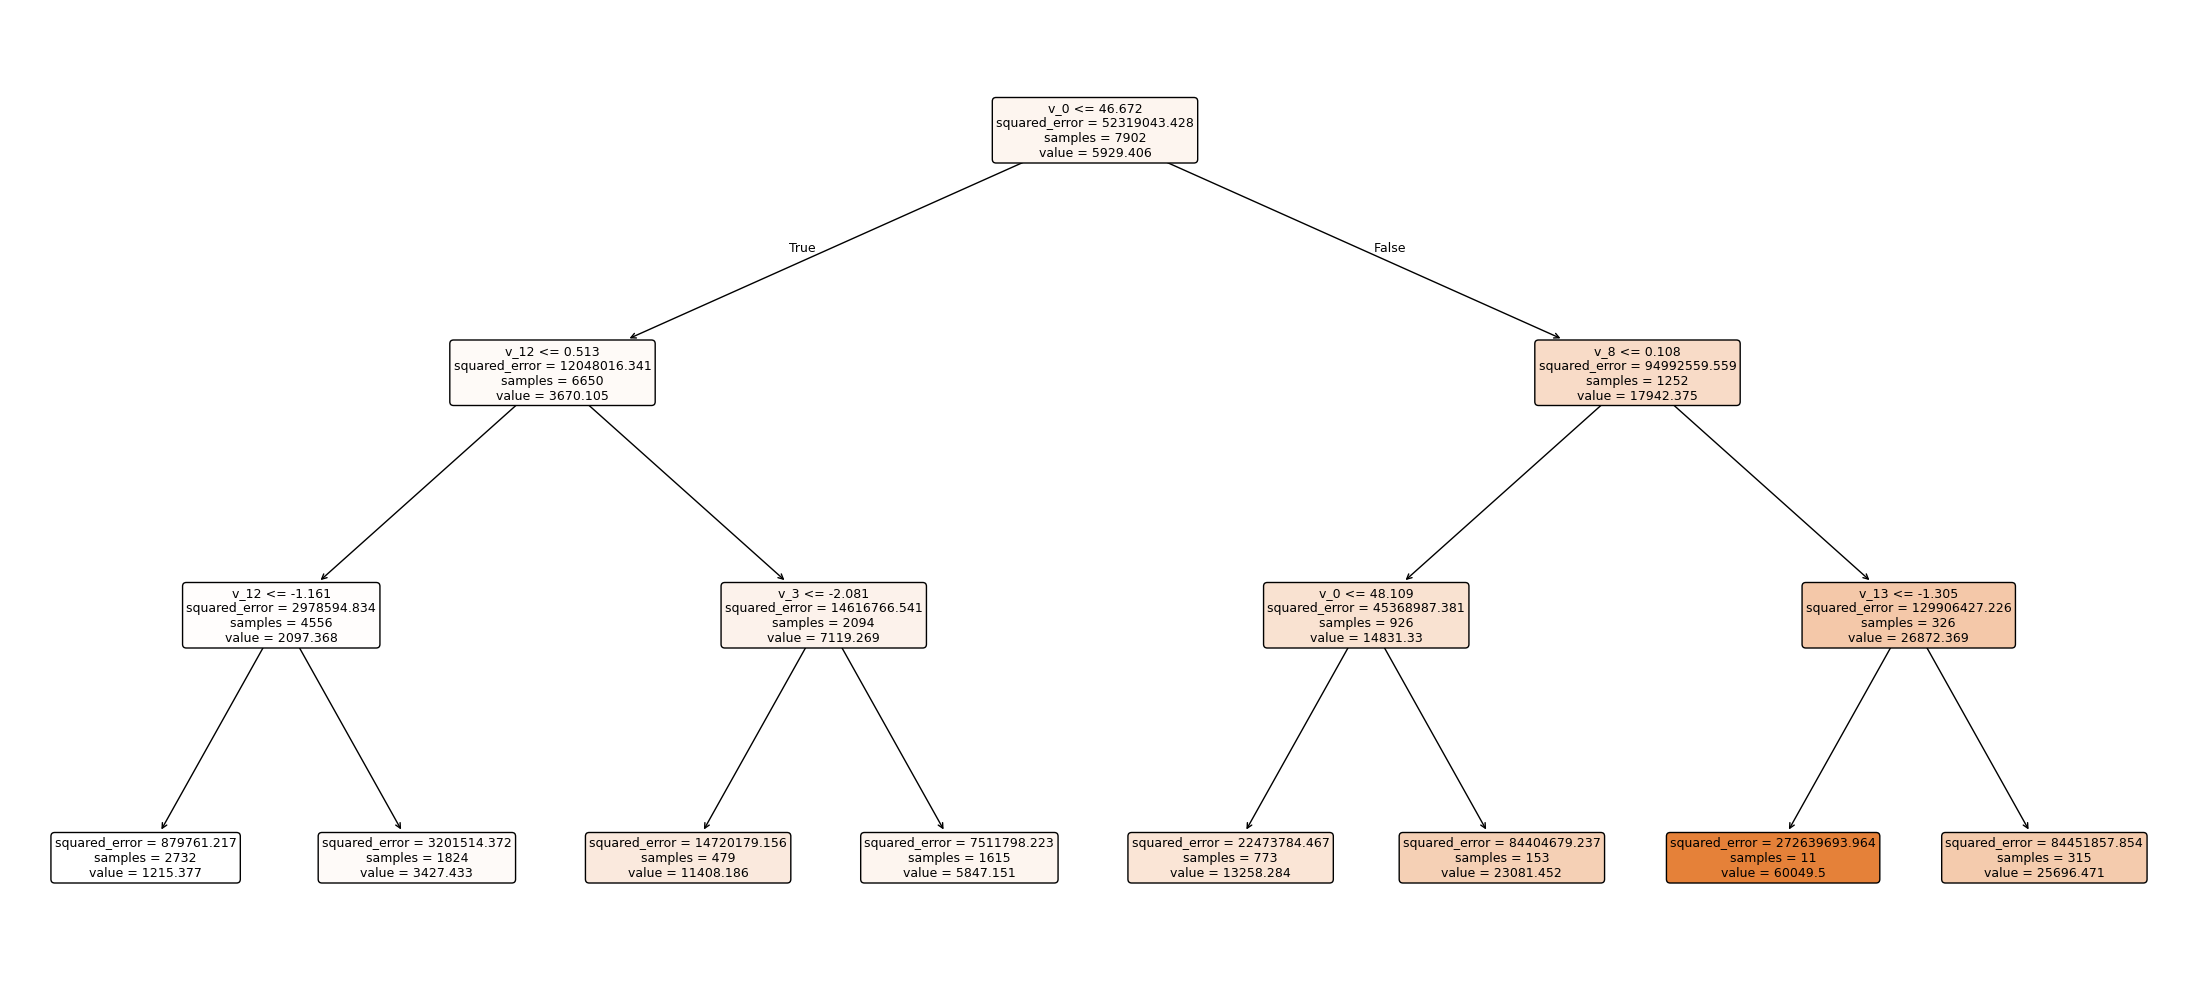

In [31]:
draw_tree(model_rf.estimators_[0], X_small.columns.tolist(), precision = 3)

`max_depth=10 + ccp_alpha=0.0 + min_samples_leaf=1` means that the tree can be subdivided infinitely, almost "perfectly fitting" the training data.

In [32]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error', # 'mse', 
    splitter = 'best', 
    max_depth = 10,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    random_state = 42,
    ccp_alpha = 0.0, 
)

In [33]:
model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

RMSE on train set: 1132.4161
RMSE on valid set: 2204.1167
R^2 on train set: 0.9741
R^2 on valid set: 0.9010


Still typical overfitting

This time max_depth no limit. The tree will continue to split until each leaf has only one sample.

min_samples_leaf=1 → Allows extreme subdivision (highest risk of overfitting).

ccp_alpha=0 → No pruning (unconstrained growth).

In [34]:
model_dt = DecisionTreeRegressor(
    criterion = 'squared_error', # 'mse', 
    splitter = 'best', 
    max_depth = None,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    random_state = 42,
    ccp_alpha = 0.0, 
)

In [35]:
model_dt.fit(X_small, y_small)
print_score(model_dt, X_small, y_small, X_valid, y_valid)

RMSE on train set: 0.0000
RMSE on valid set: 2356.4428
R^2 on train set: 1.0000
R^2 on valid set: 0.8869


This model only remembered every training set but didn't find their regular.

20 trees (n_estimators=20)

Each tree has a maximum of 15 levels (max_depth=15)

Each tree uses randomly sampled data (bootstrap=True)

In [36]:
base_model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 20, 
    criterion = 'squared_error', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time base_model.fit(X_small, y_small)
print_score(base_model, X_small, y_small, X_valid, y_valid)

CPU times: total: 7.06 s
Wall time: 813 ms
RMSE on train set: 716.8216
RMSE on valid set: 1714.1982
R^2 on train set: 0.9896
R^2 on valid set: 0.9401


In [37]:
point = X_valid.iloc[0,:]
print(point)

price = y_valid[0]
print(price, np.exp(price))

SaleID                       99703
name                         37527
model                         31.0
brand                           10
bodyType                       5.0
fuelType                       0.0
gearbox                        1.0
power                          197
kilometer                     15.0
notRepairedDamage                1
seller                           0
offerType                        0
v_0                       45.71875
v_1                      -2.744141
v_2                       -1.02832
v_3                       0.232178
v_4                      -0.860352
v_5                       0.274414
v_6                       0.007339
v_7                       0.080078
v_8                       0.060486
v_9                       0.041016
v_10                      1.678711
v_11                     -2.560547
v_12                      0.175537
v_13                     -1.209961
v_14                     -0.277832
train                          1.0
test                

In [38]:
idx = 0
x1 = X_valid.iloc[idx, :].values.reshape(1, -1)
y_pred = base_model.predict(x1)[0]
y_true = y_valid.iloc[idx] if hasattr(y_valid, "iloc") else y_valid[idx]

print("Pred:", y_pred)
print("True:", y_true)
print("Abs error:", abs(y_pred - y_true))

Pred: 3835.099512253538
True: 3499.0
Abs error: 336.0995122535378


First step: Collect prediction results for each tree

Second Step: View prediction details for a specific point

Predicted values ​​for each of the 20 trees

Overall forest prediction (equal to the average of all tree predictions)

Average of tree predictions (should be the same as above)

True label (true value)

In [39]:
# all tree predictions on all data
preds = np.stack([tree.predict(X_valid) for tree in base_model.estimators_]) # or np.asarray()

# predictions of the 20 trees, mean, and actual value (for first point in validation set)
preds[:,0], base_model.predict(point.to_frame().T)[0], np.mean(preds[:,0]), y_valid[0]

(array([6300.        , 4121.46721311, 3741.77142857, 3427.77777778,
        2700.        , 4402.21551724, 3679.23076923, 3624.5959596 ,
        3210.65384615, 3313.9       , 4326.05825243, 4019.33333333,
        4850.7791411 , 2272.63636364, 3796.89371981, 3390.        ,
        3892.85      , 4345.        , 3500.        , 3786.82692308]),
 np.float64(3835.0995122535387),
 np.float64(3835.099512253538),
 np.float64(3499.0))

The curve showing the relationship between R² and the number of trees

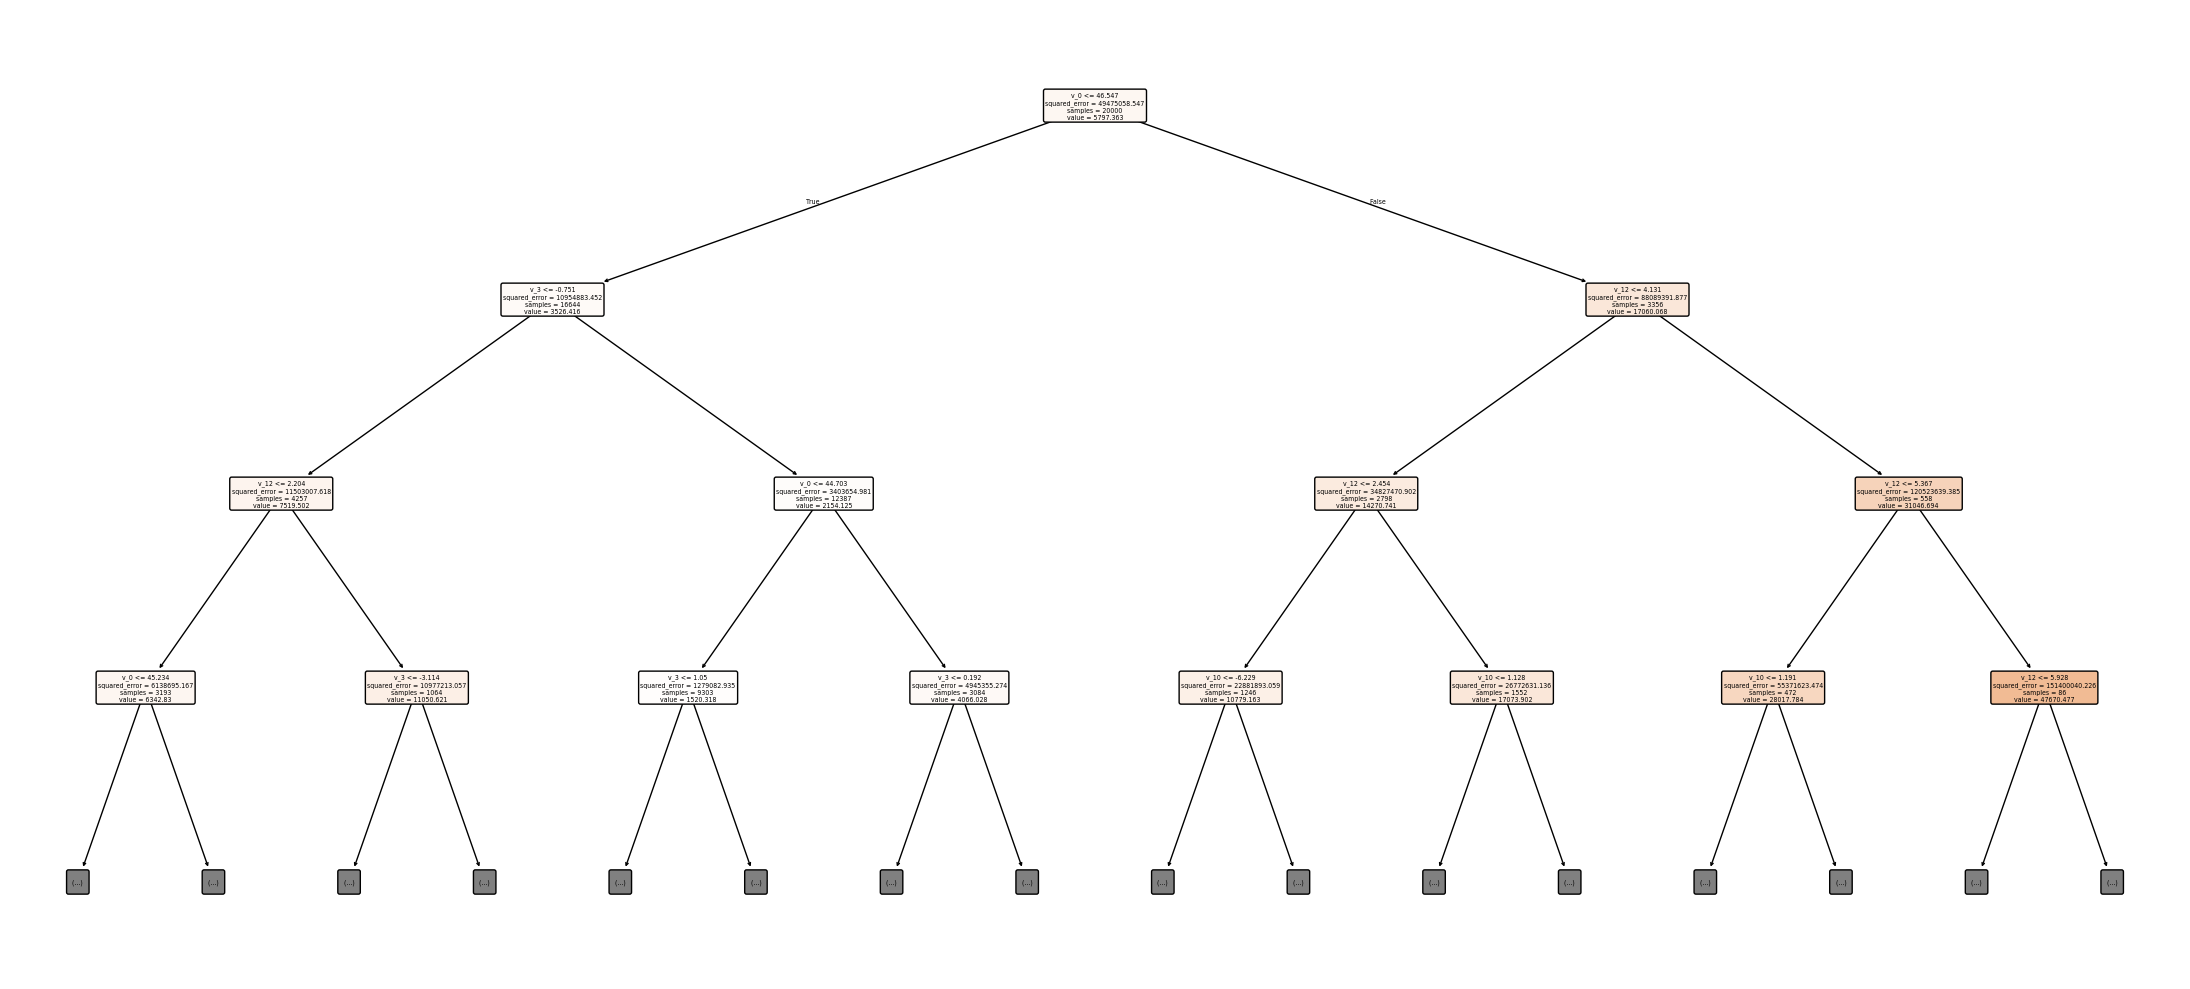

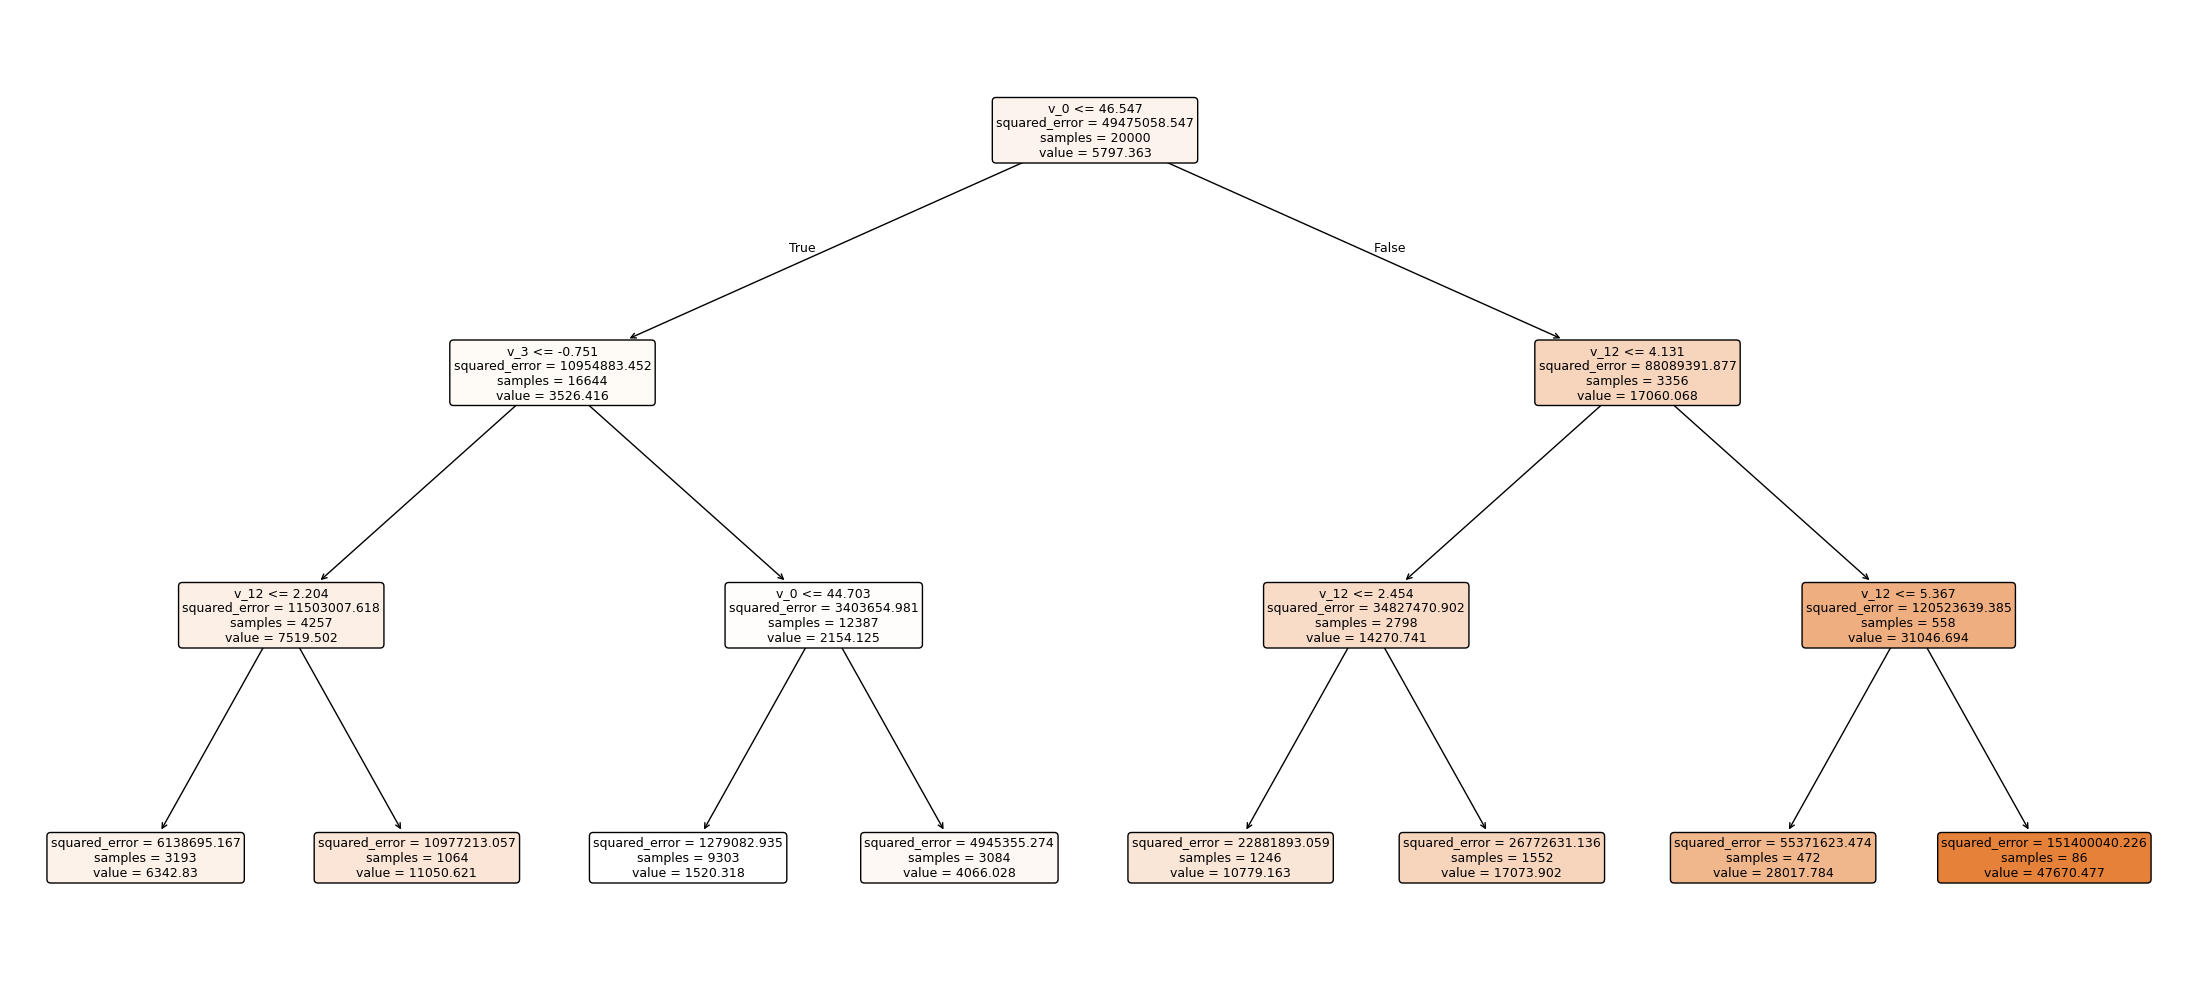

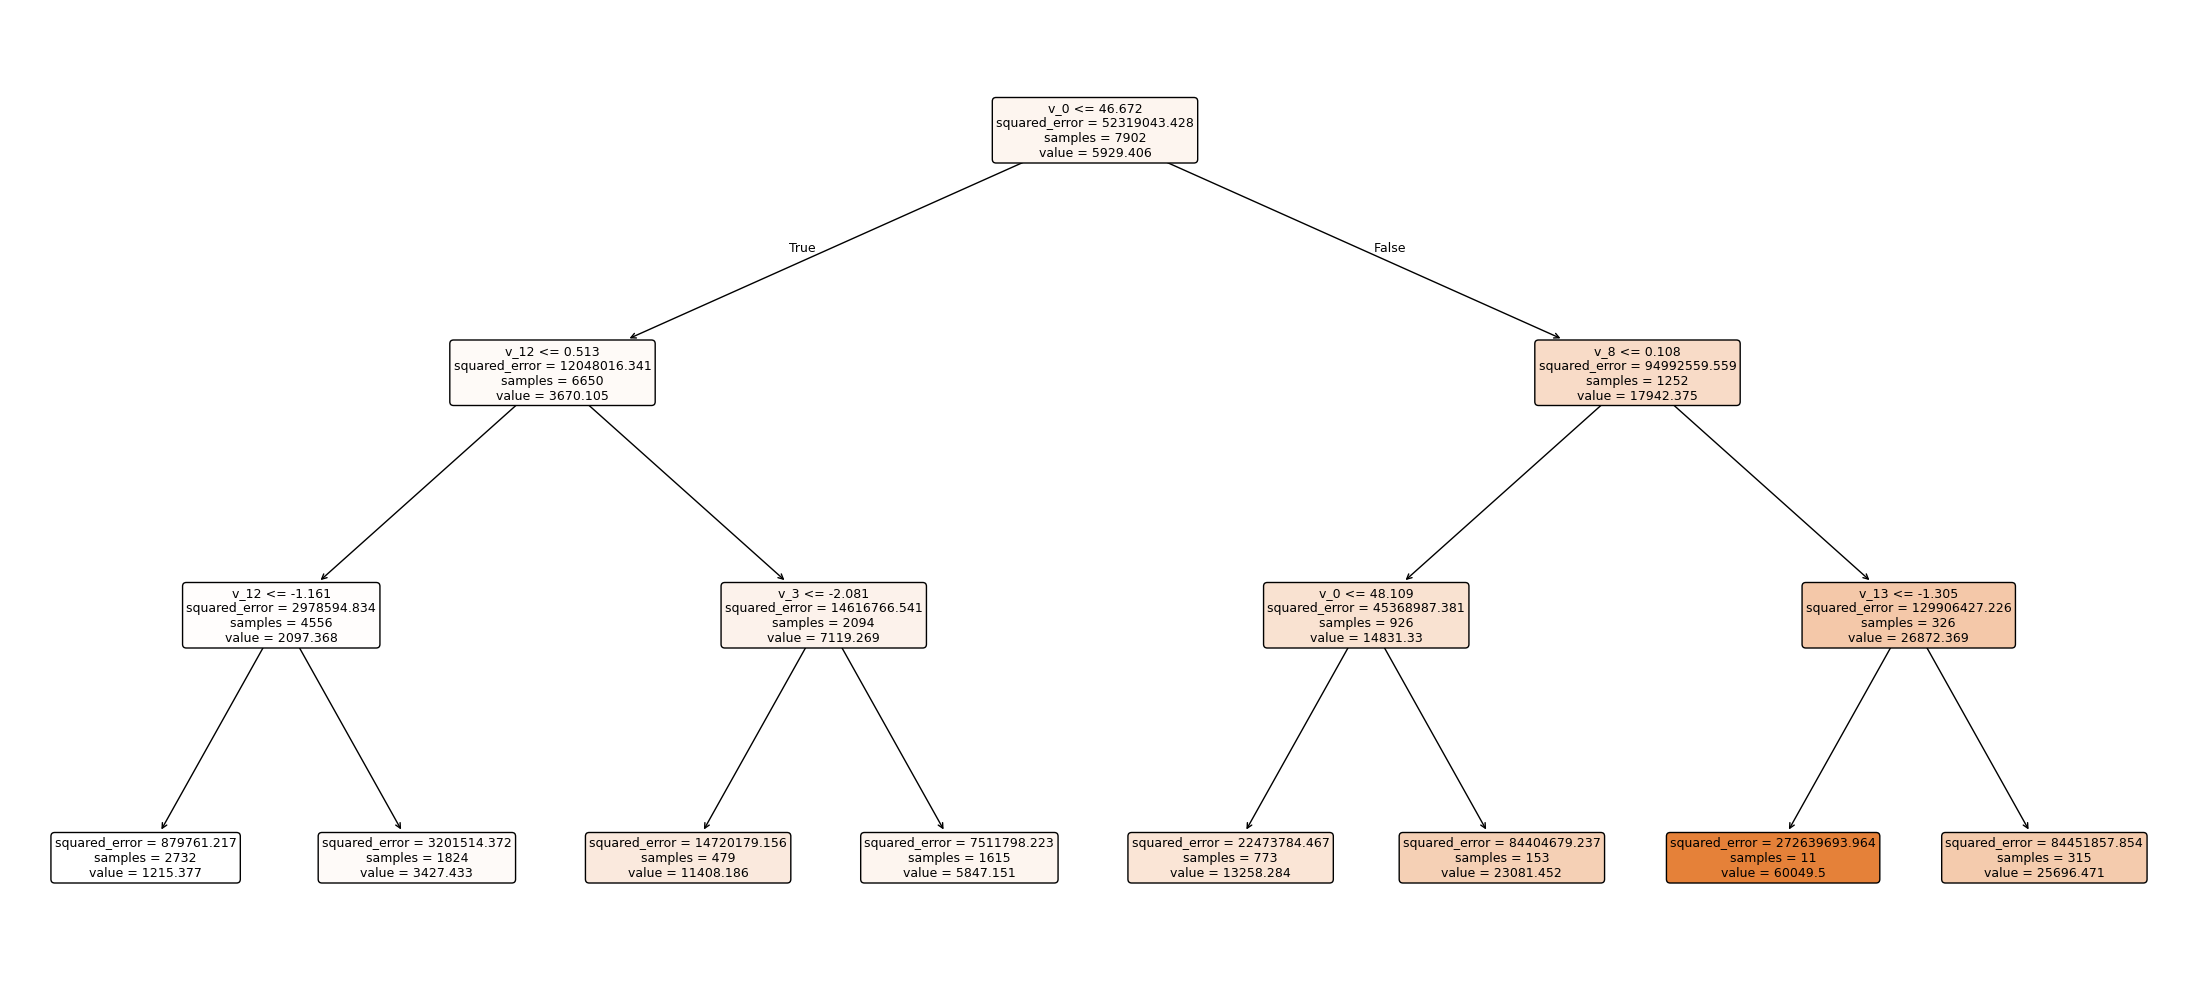

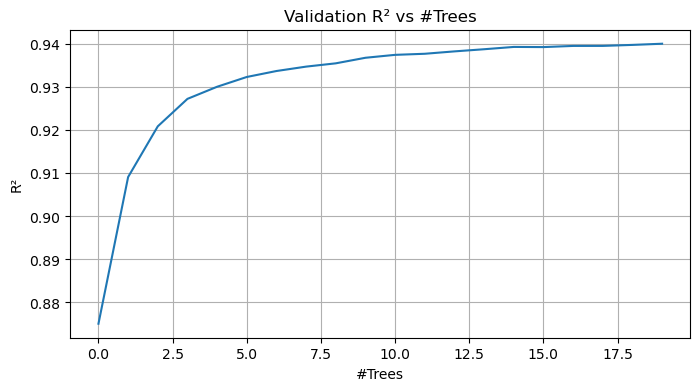

In [40]:
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis=0))
    for num_trees in range(1, 21)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close()

In [41]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 30, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 11.5 s
Wall time: 1.12 s
RMSE on train set: 705.4608
RMSE on valid set: 1701.7467
R^2 on train set: 0.9899
R^2 on valid set: 0.9410


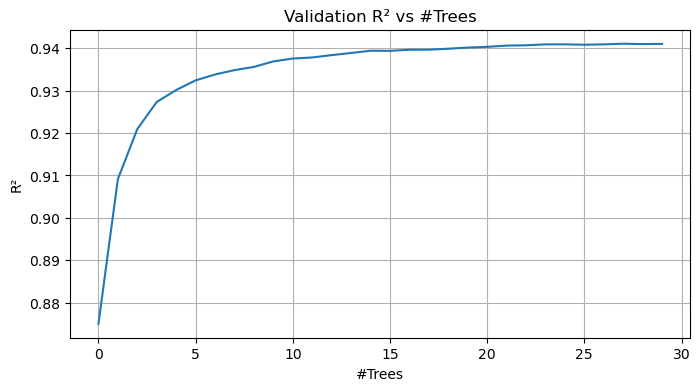

In [42]:
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]

plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis=0))
    for num_trees in range(1, 31)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close()

In [43]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 50, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42, 
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 21 s
Wall time: 1.92 s
RMSE on train set: 678.7592
RMSE on valid set: 1684.5570
R^2 on train set: 0.9907
R^2 on valid set: 0.9422


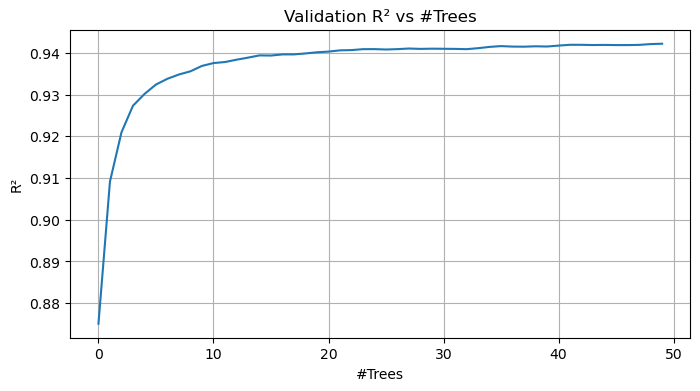

In [44]:
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis = 0)) 
    for num_trees in range(1, 51)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close() 

In [45]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 50, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1, 
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 1min 39s
Wall time: 8.81 s
RMSE on train set: 728.4754
RMSE on valid set: 1431.6369
R^2 on train set: 0.9892
R^2 on valid set: 0.9582


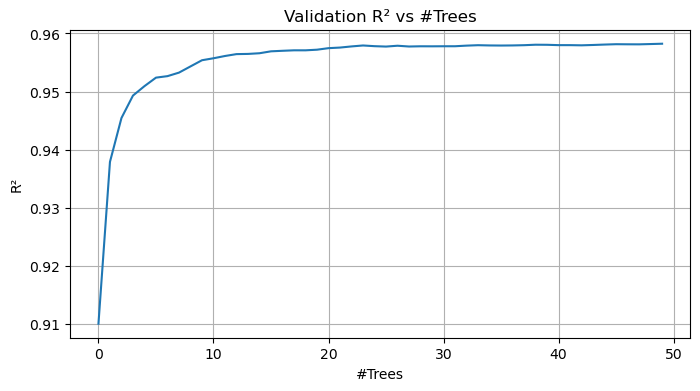

In [46]:
# all tree predictions on all data
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis = 0)) 
    for num_trees in range(1, 51)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close() 

In [47]:
model = RandomForestRegressor(
    # parameters shared with DecisionTreeRegressor
    n_estimators = 60, # 100 # 1 = the model is a single tree
    criterion = 'squared_error', 
    max_depth = 20,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0,
    ccp_alpha = 0.0, 
    random_state = 42,
    
    # RandomForestRegressor specific hyperparameters
    bootstrap = True,
    oob_score = False, 
    max_samples = None,

    # extra parameters
    warm_start = False, 
    n_jobs = -1, 
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 55s
Wall time: 14.7 s
RMSE on train set: 554.0923
RMSE on valid set: 1417.2744
R^2 on train set: 0.9937
R^2 on valid set: 0.9591


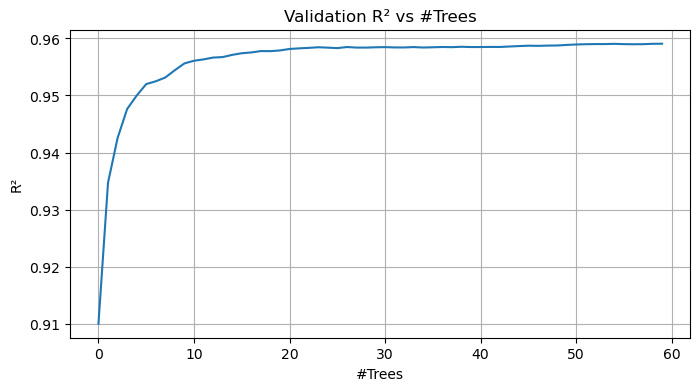

In [48]:
# all tree predictions on all data
preds = np.stack([tree.predict(X_valid) for tree in model.estimators_]) # or np.asarray()

# predictions of the 10 trees, mean, and actual value (for first point in validation set)
preds.shape, preds[:,0], np.mean(preds[:,0]), y_valid[0]
plt.figure(figsize=(8,4))
plt.plot([
    metrics.r2_score(y_valid, np.mean(preds[:num_trees], axis = 0)) 
    for num_trees in range(1, 61)
])
plt.title("Validation R² vs #Trees")
plt.xlabel("#Trees")
plt.ylabel("R²")
plt.grid(True)
plt.show()
plt.close() 

---

### OOB-Out of Bag

The samples that are not selected for each tree will serve as the "natural validation set for that tree," and will ultimately be combined into an OOB metric (R²).

1- Use small set train

In [49]:
model = RandomForestRegressor(
    n_estimators = 40, 
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False, 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 22 s
Wall time: 2.08 s
RMSE on train set: 629.0408
RMSE on valid set: 1687.7909
R^2 on train set: 0.9920
R^2 on valid set: 0.9420
R^2 on oob set: 0.9430


R² on the valid set: 0.9420 is very close to R² on the OOB set: 0.9430, indicating that OOB can approximate a standalone validation set for monitoring generalization ability.

2- Use xtrain and ytrain

In [50]:
model = RandomForestRegressor(
    n_estimators = 40, 
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False, 
    max_samples = None,
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 20s
Wall time: 12.5 s
RMSE on train set: 533.5173
RMSE on valid set: 1425.5169
R^2 on train set: 0.9942
R^2 on valid set: 0.9586
R^2 on oob set: 0.9580


In [51]:
def decision_tree_max_depth(tree):
    children_left = tree.children_left
    children_right = tree.children_right

    def walk(node_id):
        if (children_left[node_id] != children_right[node_id]):
            left_max = 1 + walk(children_left[node_id])
            right_max = 1 + walk(children_right[node_id])
            return max(left_max, right_max)
        else: # leaf
            return 1

    root_node_id = 0
    return walk(root_node_id)

In [52]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = None,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = None, 
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 21.8 s
Wall time: 2 s
RMSE on train set: 629.0408
RMSE on valid set: 1687.7909
R^2 on train set: 0.9920
R^2 on valid set: 0.9420
R^2 on oob set: 0.9430


In [53]:
tree = model.estimators_[0].tree_

decision_tree_max_depth(tree)

33

In [54]:
for i, tree in enumerate(model.estimators_):
    print('tree {} has depth {}'.format(i, decision_tree_max_depth(tree.tree_)))

tree 0 has depth 33
tree 1 has depth 37
tree 2 has depth 34
tree 3 has depth 36
tree 4 has depth 34
tree 5 has depth 34
tree 6 has depth 37
tree 7 has depth 38
tree 8 has depth 39
tree 9 has depth 32
tree 10 has depth 36
tree 11 has depth 34
tree 12 has depth 35
tree 13 has depth 35
tree 14 has depth 37
tree 15 has depth 34
tree 16 has depth 36
tree 17 has depth 34
tree 18 has depth 37
tree 19 has depth 34
tree 20 has depth 35
tree 21 has depth 36
tree 22 has depth 34
tree 23 has depth 35
tree 24 has depth 34
tree 25 has depth 35
tree 26 has depth 36
tree 27 has depth 35
tree 28 has depth 35
tree 29 has depth 34
tree 30 has depth 34
tree 31 has depth 34
tree 32 has depth 34
tree 33 has depth 34
tree 34 has depth 40
tree 35 has depth 37
tree 36 has depth 34
tree 37 has depth 32
tree 38 has depth 34
tree 39 has depth 33


The single tree is very deep (33–39 layers), with training R²≈0.99 and validation R²≈0.94;

There is no serious overfitting, but the single tree is very complex.

Now we add Regularization constraints, to do a controlled experiment

These two constraints directly control the complexity of the tree, resulting in:

1.shallower trees;

2.more stable generalization (validation/OOB);

3.shorter training time.

In [55]:
model = RandomForestRegressor(
    n_estimators = 40, 
    #Regularization constraints
    min_samples_split = 15,
    min_samples_leaf = 15,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False, 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 12.3 s
Wall time: 1.16 s
RMSE on train set: 1463.5677
RMSE on valid set: 1877.2655
R^2 on train set: 0.9567
R^2 on valid set: 0.9282
R^2 on oob set: 0.9369


Compare to the previous result:

The model has become more "stable" (slightly increased bias, significantly reduced variance);

The training error has increased → the tree no longer fully remembers the training samples (indicating that regularization is effective);

The validation/OOB ratio remains close, indicating improved generalization stability.

In [56]:
tree = model.estimators_[0].tree_

decision_tree_max_depth(tree)

20

In [57]:
for i, tree in enumerate(model.estimators_):
    print('tree {} has depth {}'.format(i, decision_tree_max_depth(tree.tree_)))

tree 0 has depth 20
tree 1 has depth 20
tree 2 has depth 22
tree 3 has depth 19
tree 4 has depth 18
tree 5 has depth 19
tree 6 has depth 19
tree 7 has depth 18
tree 8 has depth 20
tree 9 has depth 19
tree 10 has depth 18
tree 11 has depth 19
tree 12 has depth 19
tree 13 has depth 21
tree 14 has depth 20
tree 15 has depth 20
tree 16 has depth 22
tree 17 has depth 19
tree 18 has depth 21
tree 19 has depth 19
tree 20 has depth 20
tree 21 has depth 19
tree 22 has depth 18
tree 23 has depth 19
tree 24 has depth 20
tree 25 has depth 19
tree 26 has depth 20
tree 27 has depth 19
tree 28 has depth 21
tree 29 has depth 19
tree 30 has depth 20
tree 31 has depth 21
tree 32 has depth 23
tree 33 has depth 20
tree 34 has depth 20
tree 35 has depth 20
tree 36 has depth 21
tree 37 has depth 22
tree 38 has depth 19
tree 39 has depth 19


---

### A comparative experiment on sampling ratio and number of trees

1-All samples were taken from each tree (with replacement)

In [58]:
model = RandomForestRegressor(
    n_estimators = 40,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 23s
Wall time: 13 s
RMSE on train set: 533.5173
RMSE on valid set: 1425.5169
R^2 on train set: 0.9942
R^2 on valid set: 0.9586
R^2 on oob set: 0.9580


2-`max_samples=0.15` means that only 15% of the samples are randomly selected from each tree (with replacement).

In [59]:
model = RandomForestRegressor(
    n_estimators = 40,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.15, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 25.8 s
Wall time: 2.99 s
RMSE on train set: 1329.5113
RMSE on valid set: 1613.5345
R^2 on train set: 0.9639
R^2 on valid set: 0.9470
R^2 on oob set: 0.9513


3-Expanding forest size

In [60]:
model = RandomForestRegressor(
    n_estimators = 200,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.15, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 16s
Wall time: 14.5 s
RMSE on train set: 1303.1794
RMSE on valid set: 1569.9617
R^2 on train set: 0.9653
R^2 on valid set: 0.9498
R^2 on oob set: 0.9533


Forests are larger and more stable, but the marginal returns are smaller.

---

### Experiment: The impact of feature sampling ratio (max_features) and sample sampling ratio (max_samples) on model generalization ability and training stability

1.max_depth+max_samples

In [61]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = None, 
    bootstrap = True,
    oob_score = True, 
    max_samples = 0.5,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 10.3 s
Wall time: 997 ms
RMSE on train set: 1013.5554
RMSE on valid set: 1726.2987
R^2 on train set: 0.9792
R^2 on valid set: 0.9393
R^2 on oob set: 0.9457


2.max_samples=None

In [62]:
model = RandomForestRegressor(
    n_estimators = 40,
    # max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 19 s
Wall time: 1.8 s
RMSE on train set: 629.0408
RMSE on valid set: 1687.7909
R^2 on train set: 0.9920
R^2 on valid set: 0.9420
R^2 on oob set: 0.9430


3.plus max_features=0.5

In [63]:
model = RandomForestRegressor(
    n_estimators = 40,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False 
    max_samples = None,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 11.3 s
Wall time: 1.09 s
RMSE on train set: 607.7264
RMSE on valid set: 1656.9917
R^2 on train set: 0.9925
R^2 on valid set: 0.9441
R^2 on oob set: 0.9466


In [64]:
model = RandomForestRegressor(
    n_estimators = 40,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 1min 6s
Wall time: 6.07 s
RMSE on train set: 524.6491
RMSE on valid set: 1367.9668
R^2 on train set: 0.9944
R^2 on valid set: 0.9619
R^2 on oob set: 0.9596


Strong control (low variance) → Weak control (high variance) → Double randomization (low variance + strong generalization)

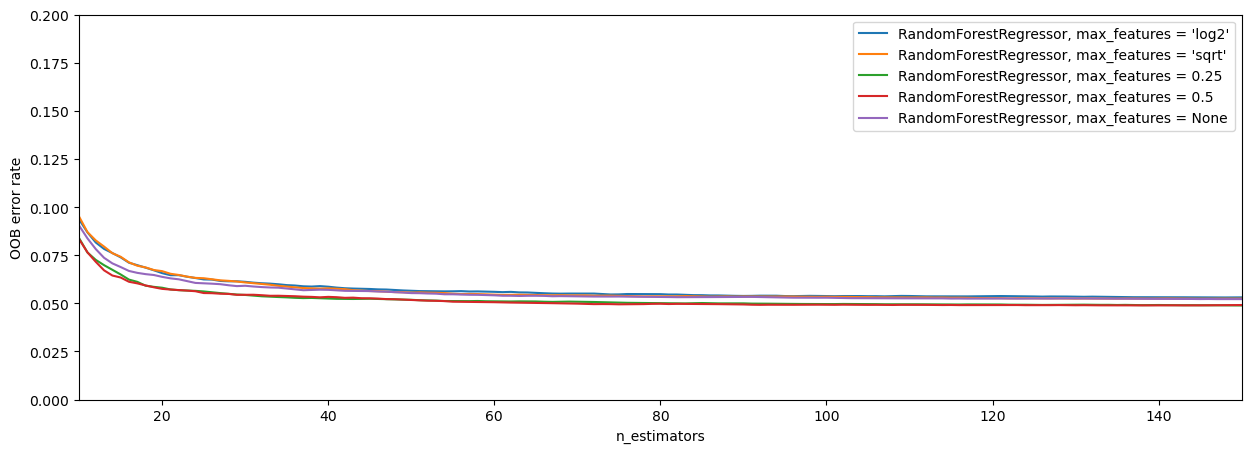

In [65]:
logging.info('warn')

# NOTE: Setting the `warm_start` construction parameter to `True` disables
# support for parallelized ensembles but is necessary for tracking the OOB
# error trajectory during training.
ensemble_clfs = [
    ("RandomForestRegressor, max_features = 'log2'",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = "log2",
            random_state = 42)),
    ("RandomForestRegressor, max_features = 'sqrt'",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = "sqrt",
            random_state = 42)),
    ("RandomForestRegressor, max_features = 0.25",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = 0.25,
            random_state = 42)),
    ("RandomForestRegressor, max_features = 0.5",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = 0.5,
            random_state = 42)),
    ("RandomForestRegressor, max_features = None",
        RandomForestRegressor(
            warm_start = True, 
            oob_score = True,
            max_features = None,
            random_state = 42)),
]

# Map a classifier name to a list of (<n_estimators>, <error rate>) pairs.
error_rate = OrderedDict((label, []) for label, _ in ensemble_clfs)

# Range of `n_estimators` values to explore.
min_estimators = 10
max_estimators = 150

for label, clf in ensemble_clfs:
    for i in range(min_estimators, max_estimators + 1):
        clf.set_params(n_estimators = i)
        clf.fit(X_small, y_small)

        # Record the OOB error for each `n_estimators=i` setting.
        oob_error = 1 - clf.oob_score_
        error_rate[label].append((i, oob_error))

# Generate the "OOB error rate" vs. "n_estimators" plot.
plt.figure(figsize = (15, 5))
for label, clf_err in error_rate.items():
    xs, ys = zip(*clf_err)
    plt.plot(xs, ys, label = label)

# Show the plot
plt.xlim(min_estimators, max_estimators)
plt.ylim(0., 0.2)
plt.xlabel("n_estimators")
plt.ylabel("OOB error rate")
plt.legend(loc = "upper right")
plt.show()

We compared Random Forests with different feature subsampling strategies (max_features) and tracked the OOB error as the number of trees grew from 10 to 150 using warm-start incremental training. The curves show diminishing returns with increasing n_estimators, and models with stronger feature subsampling (e.g., sqrt or 0.5) converged faster and achieved lower OOB error, confirming the benefit of dual randomization (samples + features) for variance reduction and generalization.

The figure illustrates the OOB error rate as a function of the number of trees (n_estimators) for different values of the feature subsampling parameter (max_features).
All models show a clear decreasing trend in OOB error that stabilizes around 70–100 trees, confirming the diminishing returns effect of increasing forest size.
Among the tested configurations, max_features = 0.5 achieved the lowest OOB error, suggesting that using roughly half of the available features at each split offers the best trade-off between tree diversity and individual tree strength.
In contrast, models with max_features = None (no feature randomness) converged slower and to a slightly higher error, highlighting the importance of feature-level randomization in Random Forests.

---

### Hyperparameter Exploration

- max_feature=None vs max_features=0.5

In [66]:
#baseline
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = None, 
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 1min 17s
Wall time: 7.15 s
RMSE on train set: 733.6358
RMSE on valid set: 1434.8049
R^2 on train set: 0.9890
R^2 on valid set: 0.9581
R^2 on oob set: 0.9577


In [67]:
model = RandomForestRegressor(
    n_estimators = 40, 
    criterion = 'squared_error', 
    
    # stoping criteria
    max_depth = 15,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0, 
 
    # bagging parameters
    max_features = 0.5, # **
    bootstrap = True,
    oob_score = True, 
    max_samples = None,
    
    # other
    warm_start = False, 
    n_jobs = -1,
    random_state = 42,
    verbose = 0, 
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 38.7 s
Wall time: 3.87 s
RMSE on train set: 736.6530
RMSE on valid set: 1396.0177
R^2 on train set: 0.9889
R^2 on valid set: 0.9603
R^2 on oob set: 0.9586


`max_features=0.5` → Each node uses only 50% of its features for splitting

Advantages: Increases diversity among trees, reducing variance

Disadvantages: Slightly reduces the fitting ability of a single tree (slightly increases bias)

Now controlling min_samples_split, max_samples, and n_estimators

In [68]:
model = RandomForestRegressor(
    n_estimators = 100, # increase n_estimators
    min_samples_split = 10, #limit overfitting
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.75, # default = None
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 17.1 s
Wall time: 1.69 s
RMSE on train set: 977.3789
RMSE on valid set: 1700.9019
R^2 on train set: 0.9807
R^2 on valid set: 0.9411
R^2 on oob set: 0.9482


In [69]:
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 15,#stronger regularization
    max_features = 0.75, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.75, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 34s
Wall time: 13.9 s
RMSE on train set: 922.7710
RMSE on valid set: 1426.9717
R^2 on train set: 0.9826
R^2 on valid set: 0.9585
R^2 on oob set: 0.9595


Test whether increasing the number of trees still yields significant benefits, or whether the convergence point has been reached.

In [70]:
model = RandomForestRegressor(
    n_estimators = 150, # increase n_estimators
    min_samples_split = 10,
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = 0.75, # default = None
)

%time model.fit(X_train, y_train)
print_score(model, X_train, y_train, X_valid, y_valid)

CPU times: total: 2min 34s
Wall time: 14.6 s
RMSE on train set: 845.2825
RMSE on valid set: 1402.2532
R^2 on train set: 0.9854
R^2 on valid set: 0.9599
R^2 on oob set: 0.9608


In [71]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 2, #almost no limitation
    max_features = 0.5, # default = None
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False 
    max_samples = None,# use all data
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 29.8 s
Wall time: 2.7 s
RMSE on train set: 577.8962
RMSE on valid set: 1648.0481
R^2 on train set: 0.9932
R^2 on valid set: 0.9447
R^2 on oob set: 0.9508


| Model                           | n_estimators | min_samples_split | max_features | max_samples | RMSE(train) | RMSE(valid) | R²(train) | R²(valid) | R²(oob) |
| ---------------------------- | ------------ | ----------------- | ------------ | ----------- | ----------- | ----------- | --------- | --------- | ------- |
|① Regularized (mild)    | 100          | 10                | 0.5          | 0.75        | 977         | 1700        | 0.981     | 0.941     | 0.948   |
| ② Regularized (stronger) | 100          | 15                | 0.75         | 0.75        | 923         | 1427        | 0.983     | 0.958     | 0.960   |
| ③ Larger forest          | 150          | 10                | 0.5          | 0.75        | 845         | 1402        | 0.986     | 0.961     | 0.961   |
| ④ Native baseline        | 100          | 2                 | 0.5          | None        | 578         | 1648        | 0.992     | 0.956     | 0.950   |


| Model | R²_train | R²_valid | distance    |
| --- | -------- | -------- | ----- |
| ①   | 0.981    | 0.941    | 0.040 |
| ②   | 0.983    | 0.958    | 0.025 |
| ③   | 0.986    | 0.961    | 0.025 |
| ④   | 0.992    | 0.956    | 0.036 |


Even though the native Random Forest (with minimal constraints) achieved the lowest training RMSE (≈577), it suffered from mild overfitting, as indicated by a higher validation RMSE (≈1648) and a larger train–validation R² gap.
In contrast, the more regularized model (n_estimators=150, min_samples_split=10, max_features=0.5, max_samples=0.75) reached the lowest validation RMSE (≈1402) and the highest OOB R² (≈0.961), demonstrating the best generalization ability.
Therefore, this configuration represents the optimal trade-off between bias and variance for our dataset.

---

### Random Forest = Bagging + Decision Tree + (optional) Feature Subsampling

In [72]:
# Random Forest built using the Bagging meta-model - Same as previous native RF
base_model = DecisionTreeRegressor(
    criterion = 'squared_error',
    splitter = 'best', 
    max_depth = None,
    min_samples_split = 2, 
    min_samples_leaf = 1,
    min_weight_fraction_leaf = 0.0, 
    max_features = None, 
    max_leaf_nodes = None, 
    min_impurity_decrease = 0.0, 
    ccp_alpha = 0.0,
    random_state = 42,
)

model = BaggingRegressor(
    estimator = base_model, 
    n_estimators = 100, 

    max_features = 0.5, 
    max_samples = 1.0, 
    
    bootstrap = True, 
    bootstrap_features = False, 
    oob_score = True, 
    
    warm_start = False, 
    n_jobs = -1, 
    random_state = 42, 
    verbose = 0,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 859 ms
Wall time: 6.42 s
RMSE on train set: 595.1836
RMSE on valid set: 1698.8810
R^2 on train set: 0.9928
R^2 on valid set: 0.9412
R^2 on oob set: 0.9476


### Bagging + Linear Regression

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

In [74]:
# Bagged model using Linear Regression as base model
base_model = LinearRegression()

model = BaggingRegressor(
    estimator = base_model, 
    n_estimators = 100, 

    max_features = 0.5, 
    max_samples = 1.0, 
    
    bootstrap = True, 
    bootstrap_features = False, 
    oob_score = True, 
    
    warm_start = False, 
    n_jobs = -1, 
    random_state = 42, 
    verbose = 0,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 406 ms
Wall time: 734 ms
RMSE on train set: 3702.3902
RMSE on valid set: 3717.8775
R^2 on train set: 0.7229
R^2 on valid set: 0.7184
R^2 on oob set: 0.7214


While linear models combined with bagging are stable, their expressive power is limited (they cannot capture non-linear relationships).

Therefore, their overall performance is worse than random forests, but they are very stable.

### Bagging + MLP (Neural Networks)

In [75]:
# Bagged model using MLP as base model
base_model = MLPRegressor(hidden_layer_sizes = (100, 50), activation = 'tanh')

model = BaggingRegressor(
    estimator = base_model, 
    n_estimators = 10, 

    max_features = 0.5, 
    max_samples = 1.0, 
    
    bootstrap = True, 
    bootstrap_features = False, 
    oob_score = True, 
    
    warm_start = False, 
    n_jobs = -1, 
    random_state = 42, 
    verbose = 0,
)

%time model.fit(X_small, y_small)
print_score(model, X_small, y_small, X_valid, y_valid)

CPU times: total: 266 ms
Wall time: 17.8 s
RMSE on train set: 8507.3654
RMSE on valid set: 8467.2275
R^2 on train set: -0.4629
R^2 on valid set: -0.4608
R^2 on oob set: -0.4650


This indicates that the neural network (MLP) failed to learn any patterns in the data.

---
## Cross-validation experiment

- Default vs. Custom Cross-Validation

In [76]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)

In [77]:
# default is cv = 5
scores = cross_val_score(model, X_small, y_small, cv = 8, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95710752 0.94901528 0.92849013 0.94677064 0.94890977 0.95522757
 0.94008675 0.94486876]
r2 is 0.946 with a standard deviation of 0.008


- randomized k-fold

In [78]:
# randomized splitting strategy
cv = KFold(n_splits = 8, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95396279 0.95684433 0.94643905 0.94922401 0.94502223 0.92428255
 0.94352329 0.95561999]
r2 is 0.947 with a standard deviation of 0.010


- add max_depth limitation

In [79]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 3, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.86102527 0.86364659 0.87432156 0.84507887 0.86214321]
r2 is 0.861 with a standard deviation of 0.009


In [80]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 10, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95046982 0.9432983  0.94501684 0.92685595 0.94358089]
r2 is 0.942 with a standard deviation of 0.008


- different scoring

In [81]:
# native Random Forest
model = RandomForestRegressor(
    n_estimators = 100,
    max_depth = 20, 
    min_samples_split = 2,
    max_features = None,
    n_jobs = -1, 
    random_state = 42,
    
    bootstrap = True,
    oob_score = True, # default = False
    max_samples = None,
)


# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(model, X_small, y_small, cv = cv, n_jobs = -1)
print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95423818 0.94592615 0.94825002 0.93008125 0.94836624]
r2 is 0.945 with a standard deviation of 0.008


use $R^2$: Explanation of variance percentage (overall fit)

In [82]:
scores = cross_val_score(model, X_small, y_small, cv = 8, scoring = 'r2', n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95654469 0.9491909  0.92861285 0.94650426 0.94855251 0.95502916
 0.94054927 0.94456918]
r2 is 0.946 with a standard deviation of 0.008


use RMSE: Actual error magnitude (units consistent with the original target)

In [83]:
scores = cross_val_score(model, X_small, y_small, cv = 8, scoring = 'neg_root_mean_squared_error', n_jobs = -1)

print(scores)
print("RMSE is {:.3f} with a standard deviation of {:.3f}".format(-scores.mean(), scores.std()))

[-1501.94095428 -1599.48166499 -1851.39120397 -1647.51228088
 -1521.42613279 -1394.54144909 -1824.97279086 -1669.7168358 ]
RMSE is 1626.373 with a standard deviation of 147.210


---

## Hyperparameter tuning

In [84]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': None,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': True,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [85]:
# several grids can be cast into a list
# here we provide only one grid
param_grid = [
    {'n_estimators': [10, 50, 60, 100],
     'max_depth': [10, 15, 20, None],
     'min_samples_split': [2, 10],
     'max_features': [0.4, 0.75, 1.],
     'max_samples': [0.4, 0.75, 1.],
    },
]

model = RandomForestRegressor(
    random_state = 42,
    bootstrap = True,
)

In [86]:
tuned_model = GridSearchCV(
    estimator = model, 
    param_grid = param_grid, 
    scoring = None, # uses estimator's default score method
    n_jobs = -1, 
    refit = True, # keep a fitted version of the overall best model
    cv = 5, 
    return_train_score = True,
    verbose = 2,
)

1. Take a set of parameters from param_grid

2. Perform 5-fold cross-validation on the training set X_small, y_small

3. Calculate the average R² for each fold

4. Repeat 288 times

5. Record the performance of each set of parameters

6. Find the set of parameters with the highest average R²

In [87]:
tuned_model.fit(X_small, y_small)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"[{'max_depth': [10, 15, ...], 'max_features': [0.4, 0.75, ...], 'max_samples': [0.4, 0.75, ...], 'min_samples_split': [2, 10], ...}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [88]:
best_model = tuned_model.best_estimator_
best_model

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
print_score(best_model, X_small, y_small, X_valid, y_valid)

RMSE on train set: 583.7586
RMSE on valid set: 1660.4663
R^2 on train set: 0.9931
R^2 on valid set: 0.9438


Cross-validation (re-checking stability)

In [90]:
# randomized splitting strategy
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

scores = cross_val_score(best_model, X_small, y_small, cv = cv, n_jobs = -1)

print(scores)
print("r2 is {:.3f} with a standard deviation of {:.3f}".format(scores.mean(), scores.std()))

[0.95407855 0.94996038 0.95037168 0.93739966 0.9505263 ]
r2 is 0.948 with a standard deviation of 0.006


Save model

In [91]:
import joblib

joblib.dump(best_model, 'best_model.joblib')

['best_model.joblib']